In [16]:
# =============================================================================
# CELL 1: Generalized System Setup using Custom MATPOWER Text Parser
# =============================================================================
import os
import re
import numpy as np

def parse_matpower_matrix(content, matrix_name):
    """Extracts a matrix from the .m file content using regex and cleans out comments."""
    pattern = rf'mpc\.{matrix_name}\s*=\s*\[(.*?)\];'
    match = re.search(pattern, content, re.DOTALL)
    
    if not match:
        return []
    
    matrix_str = match.group(1)
    # Remove inline comments (anything after %)
    matrix_str = re.sub(r'%.*', '', matrix_str)
    
    rows = []
    # Split by lines or semicolons to safely handle formatted .m files
    for line in matrix_str.replace(';', '\n').split('\n'):
        clean_line = line.strip()
        if clean_line:
            rows.append([float(val) for val in clean_line.split()])
            
    return np.array(rows)

def load_case_data(filepath):
    """Reads baseMVA, bus, gen, and branch data directly from a plain-text .m file."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Case file not found: {filepath}")
        
    with open(filepath, 'r') as f:
        content = f.read()
        
    # 1. Extract baseMVA
    base_match = re.search(r'mpc\.baseMVA\s*=\s*([\d\.]+);', content)
    baseMVA = float(base_match.group(1)) if base_match else 100.0
    
    # 2. Extract standard matrices using your parser
    bus_data = parse_matpower_matrix(content, 'bus')
    gen_data = parse_matpower_matrix(content, 'gen')
    branch_data = parse_matpower_matrix(content, 'branch')
    
    return baseMVA, bus_data, gen_data, branch_data

# --- LOAD SPECIFIC CASE FILE ---
# Update this path if your WB5.m file is in a different folder
filepath = 'WB5.m' 
baseMVA, bus_data, gen_data, branch_data = load_case_data(filepath)

# 1. Convert MATLAB 1-based indices to Python 0-based indices
bus_data[:, 0] -= 1
gen_data[:, 0] -= 1
branch_data[:, 0] -= 1
branch_data[:, 1] -= 1

# 2. Convert physical powers (MW / MVAR) to per-unit using baseMVA
# Bus load demand (Pd, Qd -> cols 2 and 3)
bus_data[:, 2] /= baseMVA
bus_data[:, 3] /= baseMVA

# Gen dispatch and limits (Pg, Qg, Qmax, Qmin, Pmax, Pmin -> cols 1, 2, 3, 4, 8, 9)
gen_data[:, [1, 2, 3, 4, 8, 9]] /= baseMVA

# Branch thermal limits (rateA -> col 5). If 0, replace with unconstrained limit.
if branch_data.shape[1] > 5:
    branch_data[:, 5] /= baseMVA
    branch_data[branch_data[:, 5] == 0, 5] = 1e10

# 3. Build Admittance Matrix (Ybus)
n_buses = len(bus_data)
Ybus = np.zeros((n_buses, n_buses), dtype=complex)
for row in branch_data:
    f, t = int(row[0]), int(row[1])
    r, x, bc = row[2], row[3], row[4]
    y_s = 1.0 / (r + 1j * x)
    y_sh = 1j * bc / 2.0
    Ybus[f, f] += y_s + y_sh
    Ybus[t, t] += y_s + y_sh
    Ybus[f, t] -= y_s
    Ybus[t, f] -= y_s

print(f"✔ Cell 1 Executed: Read {filepath} directly into per-unit NumPy arrays.")
print(f"  System baseMVA: {baseMVA} MVA | Extracted Buses: {n_buses} | Generators: {len(gen_data)}")

✔ Cell 1 Executed: Read WB5.m directly into per-unit NumPy arrays.
  System baseMVA: 100.0 MVA | Extracted Buses: 5 | Generators: 2


In [17]:
# =============================================================================
# CELL 2: Step 1 - Automated Control Space Discretization (Section III-A)
# =============================================================================
import numpy as np

# 1. Automatically identify active online generators (G)
active_gens = gen_data[gen_data[:, 7] == 1]
gen_buses = active_gens[:, 0].astype(int)

# 2. Automatically select Slack Bus (S) per Footnote 3: Max (P_max - P_min)
p_ranges = active_gens[:, 8] - active_gens[:, 9] # P_max - P_min
slack_idx_in_gen = np.argmax(p_ranges)           # Index in gen_data
slack_bus = int(active_gens[slack_idx_in_gen, 0])
non_slack_gens = np.delete(active_gens, slack_idx_in_gen, axis=0)

print(f"--- Automated Topology Analysis ---")
print(f"Total Buses: {n_buses} | Generator Buses (G): {gen_buses.tolist()}")
print(f"Selected Slack Bus (S): Bus {slack_bus+1} (Max P_range = {p_ranges[slack_idx_in_gen]:.2f} pu)")
print(f"Non-Slack Generators (G \\ S): {(non_slack_gens[:, 0] + 1).astype(int).tolist()}")
print("-----------------------------------\n")

# 3. Dynamically assemble the independent control vector u and its bounds
control_names = []
u_min = []
u_max = []

# Calculate total system active power demand to set intelligent plotting windows
total_load_pu = np.sum(bus_data[:, 2])

# Rule A: Discretize active power P_Gi for all non-slack generators (i in G \ S)
for gen in non_slack_gens:
    bus_id = int(gen[0])
    control_names.append(f"P_G{bus_id+1}")
    u_min.append(gen[9]) # P_min (col 9)
    
    # EXPLORATION WINDOW OVERRIDE:
    # Structural P_max in WB5 is 50.0 pu. Sweeping up to 50.0 pu when total load is 3.25 pu
    # wastes over 90% of grid solves. We intelligently clip the search window to 4.0 pu!
    plot_p_ceiling = min(gen[8], max(4.0, total_load_pu * 1.25))
    u_max.append(plot_p_ceiling)

# Rule B: Discretize voltage magnitude V_i for ALL generators (i in G)
for gen in active_gens:
    bus_id = int(gen[0])
    bus_row = bus_data[bus_data[:, 0] == bus_id][0]
    control_names.append(f"V_G{bus_id+1}")
    
    # FIXED: In standard 13-column MATPOWER bus matrices, Vmin is col 12 and Vmax is col 11!
    # If using a compact 6-column matrix, Vmin is col 5 and Vmax is col 4.
    vmin_idx = 12 if len(bus_row) >= 13 else 5
    vmax_idx = 11 if len(bus_row) >= 13 else 4
    
    u_min.append(bus_row[vmin_idx])
    u_max.append(bus_row[vmax_idx])

u_min = np.array(u_min)
u_max = np.array(u_max)
num_controls = len(control_names)

print(f"Automated Control Vector u ({num_controls} variables extracted):")
for i in range(num_controls):
    print(f"  [{i+1}] {control_names[i]}: Search Window [{u_min[i]:.3f}, {u_max[i]:.3f}] pu")

# 4. Programmatically build the N-dimensional discretization grid
N_res = 15  # Resolution per axis

# Generate a list of 1D linear sweeps for each extracted variable
d_sweeps = [np.linspace(u_min[i], u_max[i], N_res) for i in range(num_controls)]

# Create the N-dimensional meshgrid dynamically
mesh_grids = np.meshgrid(*d_sweeps, indexing='ij')

# Flatten all grids and stack them into an (M x d) array of candidate vectors
candidate_controls = np.vstack([grid.ravel() for grid in mesh_grids]).T

print(f"\n✔ Step 1 Complete: Programmatically generated {len(candidate_controls):,} grid coordinates.")
print("\nPreview of first 5 automated candidate control vectors (u^k):")
print("-" * 65)
for k in range(5):
    formatted_vals = " | ".join([f"{control_names[i]} = {candidate_controls[k, i]:.3f}" for i in range(num_controls)])
    print(f"  Candidate {k+1:04d}: {formatted_vals}")
print("-" * 65)

--- Automated Topology Analysis ---
Total Buses: 5 | Generator Buses (G): [0, 4]
Selected Slack Bus (S): Bus 1 (Max P_range = 50.00 pu)
Non-Slack Generators (G \ S): [5]
-----------------------------------

Automated Control Vector u (3 variables extracted):
  [1] P_G5: Search Window [0.000, 4.062] pu
  [2] V_G1: Search Window [0.950, 1.050] pu
  [3] V_G5: Search Window [0.950, 1.050] pu

✔ Step 1 Complete: Programmatically generated 3,375 grid coordinates.

Preview of first 5 automated candidate control vectors (u^k):
-----------------------------------------------------------------
  Candidate 0001: P_G5 = 0.000 | V_G1 = 0.950 | V_G5 = 0.950
  Candidate 0002: P_G5 = 0.000 | V_G1 = 0.950 | V_G5 = 0.957
  Candidate 0003: P_G5 = 0.000 | V_G1 = 0.950 | V_G5 = 0.964
  Candidate 0004: P_G5 = 0.000 | V_G1 = 0.950 | V_G5 = 0.971
  Candidate 0005: P_G5 = 0.000 | V_G1 = 0.950 | V_G5 = 0.979
-----------------------------------------------------------------


In [18]:
# =============================================================================
# CELL 3: Step 2 - Formulating the Square Polynomial System (Section III-B)
# =============================================================================
# We create a universal function that maps 2n-2 unknown voltage states (x)
# to 2n-2 quadratic power flow residuals for any candidate control vector (u_k).

def get_state_mapping(n_buses, slack_bus):
    """Creates indexing maps to move between full 2n voltages and 2n-2 unknown states."""
    all_buses = np.arange(n_buses)
    unknown_buses = np.delete(all_buses, slack_bus)
    return unknown_buses

def unpack_voltages(state_x, u_k, n_buses, slack_bus, active_gens, control_names):
    """Reconstructs full Vd and Vq arrays (size n) from the 2n-2 unknown states and fixed u_k."""
    unknown_buses = get_state_mapping(n_buses, slack_bus)
    
    Vd = np.zeros(n_buses)
    Vq = np.zeros(n_buses)
    
    # 1. Assign the 2n-2 unknown state variables to non-slack buses
    num_unknown = len(unknown_buses)
    Vd[unknown_buses] = state_x[:num_unknown]
    Vq[unknown_buses] = state_x[num_unknown:]
    
    # 2. Assign fixed Slack Bus voltages (V_q = 0, V_d = V_slack from u_k)
    slack_control_name = f"V_G{slack_bus+1}"
    slack_idx_in_u = control_names.index(slack_control_name)
    Vd[slack_bus] = u_k[slack_idx_in_u]
    Vq[slack_bus] = 0.0
    
    return Vd, Vq

def power_flow_residuals(state_x, u_k, bus_data, gen_data, Ybus, slack_bus, active_gens, non_slack_gens, control_names):
    """
    Evaluates the 2n-2 quadratic polynomial equations (Equation 6 in Molzahn 2017).
    Returns an array of 2n-2 residuals: F(x) = 0.
    """
    n_buses = len(bus_data)
    G, B = Ybus.real, Ybus.imag
    Vd, Vq = unpack_voltages(state_x, u_k, n_buses, slack_bus, active_gens, control_names)
    
    # Calculate active (P_calc) and reactive (Q_calc) injections at all buses
    # Equations (2a) and (2b) in paper
    P_calc = np.zeros(n_buses)
    Q_calc = np.zeros(n_buses)
    for i in range(n_buses):
        for k in range(n_buses):
            P_calc[i] += Vd[i] * (G[i,k]*Vd[k] - B[i,k]*Vq[k]) + Vq[i] * (B[i,k]*Vd[k] + G[i,k]*Vq[k])
            Q_calc[i] += Vd[i] * (-B[i,k]*Vd[k] - G[i,k]*Vq[k]) + Vq[i] * (G[i,k]*Vd[k] - B[i,k]*Vq[k])
            
    residuals = []
    unknown_buses = get_state_mapping(n_buses, slack_bus)
    
    for i in unknown_buses:
        # Check if this bus is a generator
        is_gen = i in active_gens[:, 0]
        
        if is_gen:
            # RULE 1: Non-Slack Generator -> Match active power P_Gi from grid u_k (Eq 6a)
            p_control_name = f"P_G{i+1}"
            p_target = u_k[control_names.index(p_control_name)]
            residuals.append(P_calc[i] - p_target)
            
            # RULE 2: All Generators -> Match squared voltage magnitude |V_i|^2 from grid u_k (Eq 6b)
            v_control_name = f"V_G{i+1}"
            v_target = u_k[control_names.index(v_control_name)]
            residuals.append((Vd[i]**2 + Vq[i]**2) - (v_target**2))
            
        else:
            # RULE 3: PQ Load Buses -> Match fixed active and reactive load demand (Eq 6c, 6d)
            p_load = bus_data[bus_data[:, 0] == i, 2][0]
            q_load = bus_data[bus_data[:, 0] == i, 3][0]
            residuals.append(P_calc[i] - (-p_load))  # Generation minus load = 0 -> P_calc = -P_load
            residuals.append(Q_calc[i] - (-q_load))
            
    return np.array(residuals)

# --- Verification Test on the First Grid Candidate ---
test_u = candidate_controls[0]
test_x0 = np.ones(2 * n_buses - 2)  # Flat voltage guess of 1.0 for Vd, 0.0 for Vq

# FIXED: Corrected argument order -> pass test_x0 (state_x) first, test_u (u_k) second!
test_res = power_flow_residuals(test_x0, test_u, bus_data, gen_data, Ybus, slack_bus, active_gens, non_slack_gens, control_names)

print(f"✔ Step 2 Complete: Generalized square polynomial system built successfully.")
print(f"  System Size: {len(test_res)} equations and {len(test_x0)} unknown state variables.")
print(f"  Sample residual norm with flat voltage guess: {np.linalg.norm(test_res):.4f}")

✔ Step 2 Complete: Generalized square polynomial system built successfully.
  System Size: 8 equations and 8 unknown state variables.
  Sample residual norm with flat voltage guess: 20.7846


In [15]:
# =============================================================================
# CELL 4 (HPC PRODUCTION EDITION): Full Grid Sweep & Disk Saving
# =============================================================================
import numpy as np
import pickle
import time
import phcpy
from phcpy.solver import solve
from phcpy.solutions import coordinates

# --- HELPER 1: Calculate transmission line apparent power flows ---
def compute_branch_flows(Vd, Vq, Ybus, branch_data):
    """Calculates apparent power flows S_lm (in MVA/pu) across all transmission lines."""
    n_lines = len(branch_data)
    S_max_calc = np.zeros(n_lines)
    V_cplx = Vd + 1j * Vq
    
    for l in range(n_lines):
        f = int(branch_data[l, 0])
        t = int(branch_data[l, 1])
        r, x = branch_data[l, 2], branch_data[l, 3]
        bc = branch_data[l, 4] if branch_data.shape[1] > 4 else 0.0
        
        y_s = 1.0 / (r + 1j * x)
        y_sh = 1j * bc / 2.0
        
        I_fr = (V_cplx[f] - V_cplx[t]) * y_s + V_cplx[f] * y_sh
        I_to = (V_cplx[t] - V_cplx[f]) * y_s + V_cplx[t] * y_sh
        
        S_fr = np.abs(V_cplx[f] * np.conj(I_fr))
        S_to = np.abs(V_cplx[t] * np.conj(I_to))
        S_max_calc[l] = max(S_fr, S_to)
        
    return S_max_calc

# --- HELPER 2: Filter real roots against OPF inequality constraints ---
def filter_feasible_point(state_x, u_k, bus_data, gen_data, branch_data, Ybus, slack_bus, active_gens, control_names):
    """Checks if a converged real power flow solution satisfies all OPF inequality constraints (Eq 5)."""
    n_buses = len(bus_data)
    G, B = Ybus.real, Ybus.imag
    tol = 1e-3  # Boundary tolerance for discretized grid evaluation
    
    unknown_buses = np.delete(np.arange(n_buses), slack_bus)
    Vd, Vq = np.zeros(n_buses), np.zeros(n_buses)
    num_unknown = len(unknown_buses)
    Vd[unknown_buses] = state_x[:num_unknown]
    Vq[unknown_buses] = state_x[num_unknown:]
    
    slack_control_name = f"V_G{slack_bus+1}"
    Vd[slack_bus] = float(u_k[control_names.index(slack_control_name)])
    Vq[slack_bus] = 0.0
    
    V_mag = np.sqrt(Vd**2 + Vq**2)
    
    P_inj, Q_inj = np.zeros(n_buses), np.zeros(n_buses)
    for i in range(n_buses):
        for k in range(n_buses):
            P_inj[i] += Vd[i] * (G[i,k]*Vd[k] - B[i,k]*Vq[k]) + Vq[i] * (B[i,k]*Vd[k] + G[i,k]*Vq[k])
            Q_inj[i] += Vd[i] * (-B[i,k]*Vd[k] - G[i,k]*Vq[k]) + Vq[i] * (G[i,k]*Vd[k] - B[i,k]*Vq[k])
            
    P_gen = P_inj + bus_data[:, 2]
    Q_gen = Q_inj + bus_data[:, 3]
    
    # FILTER A: Load Bus Voltage Magnitude Limits (Eq 5d)
    for bus_row in bus_data:
        i = int(bus_row[0])
        if i not in active_gens[:, 0]:
            vmin = bus_row[12] if len(bus_row) >= 13 else bus_row[5]
            vmax = bus_row[11] if len(bus_row) >= 13 else bus_row[4]
            if not (vmin - tol <= V_mag[i] <= vmax + tol):
                return False, P_gen, Q_gen, V_mag, None
                
    # FILTER B: Generator Active & Reactive Limits (Eq 5b, 5c)
    for gen in active_gens:
        i = int(gen[0])
        if not (gen[4] - tol <= Q_gen[i] <= gen[3] + tol):
            return False, P_gen, Q_gen, V_mag, None
        if not (gen[9] - tol <= P_gen[i] <= gen[8] + tol):
            return False, P_gen, Q_gen, V_mag, None
            
    # FILTER C: Apparent Power Line Flow Limits (Eq 5e, 5f)
    S_flows = compute_branch_flows(Vd, Vq, Ybus, branch_data)
    if branch_data.shape[1] > 5:
        for l in range(len(branch_data)):
            limit = branch_data[l, 5]
            if limit > 0 and S_flows[l] > limit + tol:
                return False, P_gen, Q_gen, V_mag, S_flows

    return True, P_gen, Q_gen, V_mag, S_flows

# --- HELPER 3: Build PHCpack Algebraic Strings ---
def add_monomial(coeff, var1, var2):
    final_coeff = coeff
    symbols = []
    
    if isinstance(var1, float): final_coeff *= var1
    else: symbols.append(var1)
    if isinstance(var2, float): final_coeff *= var2
    else: symbols.append(var2)
        
    if abs(final_coeff) < 1e-10: return ""
    sign_str = "+ " if final_coeff >= 0 else "- "
    abs_c = abs(final_coeff)
    
    if len(symbols) == 0: return f"{sign_str}{abs_c:.8f}"
    elif len(symbols) == 1: return f"{sign_str}{abs_c:.8f}*{symbols[0]}"
    else:
        if symbols[0] == symbols[1]: return f"{sign_str}{abs_c:.8f}*{symbols[0]}^2"
        else: return f"{sign_str}{abs_c:.8f}*{symbols[0]}*{symbols[1]}"

def build_phcpy_system_strings(u_k, bus_data, gen_data, Ybus, slack_bus, active_gens, control_names):
    n_buses = len(bus_data)
    G, B = Ybus.real, Ybus.imag
    unknown_buses = np.delete(np.arange(n_buses), slack_bus)
    v_slack = float(u_k[control_names.index(f"V_G{slack_bus+1}")])
    
    def get_Vd(k): return v_slack if k == slack_bus else f"Vd{k+1}"
    def get_Vq(k): return 0.0 if k == slack_bus else f"Vq{k+1}"

    poly_equations = []
    for i in unknown_buses:
        p_terms, q_terms = [], []
        for k in range(n_buses):
            vd_i, vq_i = get_Vd(i), get_Vq(i)
            vd_k, vq_k = get_Vd(k), get_Vq(k)
            
            p_terms.extend([add_monomial(G[i,k], vd_i, vd_k), add_monomial(-B[i,k], vd_i, vq_k),
                            add_monomial(B[i,k], vq_i, vd_k), add_monomial(G[i,k], vq_i, vq_k)])
            q_terms.extend([add_monomial(-B[i,k], vd_i, vd_k), add_monomial(-G[i,k], vd_i, vq_k),
                            add_monomial(G[i,k], vq_i, vd_k), add_monomial(-B[i,k], vq_i, vq_k)])
            
        def clean_expr(terms_list):
            expr = " ".join([t for t in terms_list if t != ""])
            if expr.startswith("+ "): return expr[2:]
            elif expr.startswith("- "): return "-" + expr[2:]
            return expr

        P_calc_str, Q_calc_str = clean_expr(p_terms), clean_expr(q_terms)
        
        is_gen = i in active_gens[:, 0]
        if is_gen:
            p_target = float(u_k[control_names.index(f"P_G{i+1}")])
            p_target_str = f"- {p_target:.8f}" if p_target >= 0 else f"+ {abs(p_target):.8f}"
            poly_equations.append(f"{P_calc_str} {p_target_str};")
            
            v_target = float(u_k[control_names.index(f"V_G{i+1}")])
            poly_equations.append(f"Vd{i+1}^2 + Vq{i+1}^2 - {v_target**2:.8f};")
        else:
            p_load = float(bus_data[bus_data[:, 0] == i, 2][0])
            q_load = float(bus_data[bus_data[:, 0] == i, 3][0])
            p_load_str = f"+ {p_load:.8f}" if p_load >= 0 else f"- {abs(p_load):.8f}"
            q_load_str = f"+ {q_load:.8f}" if q_load >= 0 else f"- {abs(q_load):.8f}"
            
            poly_equations.append(f"{P_calc_str} {p_load_str};")
            poly_equations.append(f"{Q_calc_str} {q_load_str};")
            
    var_names = [f"Vd{i+1}" for i in unknown_buses] + [f"Vq{i+1}" for i in unknown_buses]
    return poly_equations, var_names

# --- HELPER 4: Official Documentation-Faithful Root Parser ---
def parse_phcpy_real_roots(raw_solutions, var_names):
    real_roots = []
    if not raw_solutions: return real_roots
    
    for sol in raw_solutions:
        try:
            vars_list, vals_list = coordinates(sol)
            sol_dict = dict(zip(vars_list, vals_list))
            if not all(v in sol_dict for v in var_names): continue
                
            cplx_vals = [sol_dict[v] for v in var_names]
            if all(abs(c.imag) < 1e-3 for c in cplx_vals):
                real_roots.append(np.array([c.real for c in cplx_vals]))
        except Exception:
            continue
    return real_roots

# =============================================================================
# EXECUTE FULL PRODUCTION SWEEP ACROSS ENTIRE GRID
# =============================================================================
# We evaluate ALL coordinates in candidate_controls
eval_grid = candidate_controls
total_points = len(eval_grid)
print(f"Starting Production NPHC Sweep across {total_points:,} coordinates...")
print(f"Time started: {time.strftime('%X')}\n")

feasible_points = []
start_time = time.time()

for k, u_k in enumerate(eval_grid):
    pols, var_names = build_phcpy_system_strings(u_k, bus_data, gen_data, Ybus, slack_bus, active_gens, control_names)
    raw_complex_solutions = solve(pols)
    real_roots = parse_phcpy_real_roots(raw_complex_solutions, var_names)
    
    num_feas = 0
    for sol_x in real_roots:
        is_feas, P_gen, Q_gen, V_mag, S_flows = filter_feasible_point(
            sol_x, u_k, bus_data, gen_data, branch_data, Ybus, slack_bus, active_gens, control_names
        )
        if is_feas:
            # Generation Cost Formula for WB5: Cost = 400*P_G1 + 100*P_G5 ($/h)
            cost = 400.0 * P_gen[0] + 100.0 * P_gen[4]
            feasible_points.append({
                'u_k': u_k, 'P_gen': P_gen, 'Q_gen': Q_gen, 'V_mag': V_mag, 'cost': cost
            })
            num_feas += 1
            break # Found the feasible operating point for this grid coordinate
            
    # Log progress cleanly every 50 evaluations or whenever a point is found
    if (k + 1) % 50 == 0 or num_feas > 0:
        elapsed_sec = time.time() - start_time
        rate = (k + 1) / elapsed_sec
        est_rem_min = ((total_points - (k + 1)) / rate) / 60.0
        print(f"  [Progress {(k+1):4d}/{total_points:,} | {(k+1)/total_points*100:5.1f}%] P_G5={u_k[0]:.2f} pu | Real Roots: {len(real_roots):2d} | Feasible Total: {len(feasible_points):3d} | ETA: {est_rem_min:.1f} min")

print(f"\n✔ True NPHC Production Sweep Complete!")
print(f"  Total Time Elapsed: {(time.time() - start_time)/60:.2f} minutes")
print(f"  Strictly Feasible OPF Operating Points Found: {len(feasible_points):,}")

# --- SAVE RESULTS TO DISK FOR HPC SAFETY ---
output_filename = "wb5_feasible_points.pkl"
with open(output_filename, "wb") as f:
    pickle.dump(feasible_points, f)
print(f"✔ Data successfully persisted to disk: '{output_filename}' (Safe to plot!)")

Starting Production NPHC Sweep across 3,375 coordinates...
Time started: 21:07:19



KeyboardInterrupt: 

In [ ]:
# =============================================================================
# CELL 5: 3D Feasible Space Visualization (Reproduction of Molzahn 2017, Fig. 3)
# =============================================================================
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Load data safely from disk (allows you to plot on your laptop without re-running Cell 4!)
input_filename = "wb5_feasible_points.pkl"
if os.path.exists(input_filename):
    with open(input_filename, "rb") as f:
        plot_points = pickle.load(f)
    print(f"✔ Successfully loaded {len(plot_points):,} feasible points from '{input_filename}'.")
else:
    # Fallback to in-memory list if running directly after Cell 4
    plot_points = feasible_points
    print(f"⚠️ Disk file not found. Using in-memory list ({len(plot_points):,} points).")

if len(plot_points) == 0:
    print("❌ No feasible points available to plot! Please check Cell 4 execution.")
else:
    # 2. Extract projection axes: P_G5 (horizontal), P_G1 (vertical), Q_G5 (depth)
    P_G1_vals = np.array([pt['P_gen'][0] for pt in plot_points])  # Slack Bus Active Generation
    P_G5_vals = np.array([pt['P_gen'][4] for pt in plot_points])  # Bus 5 Active Generation
    Q_G5_vals = np.array([pt['Q_gen'][4] for pt in plot_points])  # Bus 5 Reactive Generation
    cost_vals = np.array([pt['cost'] for pt in plot_points])      # $/h Generation Cost

    # Safety check: Remove any NaN or Inf costs to prevent Matplotlib Normalize warnings!
    valid_mask = ~np.isnan(cost_vals) & ~np.isinf(cost_vals)
    P_G1_vals, P_G5_vals = P_G1_vals[valid_mask], P_G5_vals[valid_mask]
    Q_G5_vals, cost_vals = Q_G5_vals[valid_mask], cost_vals[valid_mask]

    # 3. Setup 3D Figure
    fig = plt.figure(figsize=(12, 9), dpi=150)
    ax = fig.add_subplot(111, projection='3d')

    # 4. Plot Feasible Manifold Cloud (Colored by generation cost $/h)
    sc = ax.scatter(P_G5_vals, P_G1_vals, Q_G5_vals, c=cost_vals, cmap='Reds', 
                    s=35, alpha=0.9, edgecolors='k', linewidths=0.2, label='Feasible AC-OPF Manifold')

    # 5. Plot Separating Plane at Q_G5 = -0.30 pu (The Disconnected Component Boundary)
    xx, yy = np.meshgrid(np.linspace(0.0, 4.5, 10), np.linspace(0.0, 5.0, 10))
    zz = -0.30 * np.ones_like(xx)
    ax.plot_surface(xx, yy, zz, color='gray', alpha=0.25, rstride=1, cstride=1, edgecolor='none')

    # 6. Highlight Known Global Optimum (P_G1=1.81 pu, P_G5=2.21 pu, Q_G5=-0.30 pu) from Table II
    ax.scatter([2.21], [1.81], [-0.30], color='lime', s=300, marker='*', 
               edgecolors='k', linewidths=1.0, zorder=10, label='Global Optimum ($1,810/h)')
    
    # 7. Highlight Known Local Optimum (P_G1=2.46 pu, P_G5=0.98 pu, Q_G5=-0.30 pu)
    ax.scatter([0.98], [2.46], [-0.30], color='cyan', s=180, marker='^', 
               edgecolors='k', linewidths=1.0, zorder=10, label='Local Optimum (+14.3% Cost)')

    # 8. Formatting & Aesthetics
    cb = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.08)
    cb.set_label('Total Generation Cost ($/h)', fontsize=12, labelpad=10)
    
    ax.set_xlabel('$P_{G5}$ (per unit)', fontsize=12, labelpad=12)
    ax.set_ylabel('$P_{G1}$ (per unit)', fontsize=12, labelpad=12)
    ax.set_zlabel('$Q_{G5}$ (per unit)', fontsize=12, labelpad=12)
    
    # Set explicit viewing limits matching Figure 3 of Molzahn (2017)
    ax.set_xlim([0.0, 4.5])
    ax.set_ylim([0.0, 5.0])
    ax.set_zlim([-0.45, 0.8])
    
    ax.set_title("Computed Feasible Space of WB5 AC-OPF (Molzahn 2017)\n"
                 "Separating boundary plane plotted at $Q_{G5} = -0.30$ pu", fontsize=14, pad=15)
    
    # Optimal perspective angle to view the disconnected component below Q_G5 = -0.30
    ax.view_init(elev=22, azim=-52)
    ax.legend(loc='upper left', framealpha=0.95, fontsize=11)
    
    plt.tight_layout()
    
    # Save high-res figure to disk
    output_img = "WB5_Molzahn_Fig3_Replication.png"
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    print(f"✔ High-resolution Figure 3 successfully generated and saved as '{output_img}'!")
    plt.show()

In [12]:
# =============================================================================
# DIAGNOSTIC: Why are real roots failing filter_feasible_point?
# =============================================================================
print("--- AUDITING REAL ROOTS FROM NOMINAL POINT ---")

for idx, sol_x in enumerate(real_nom_sols):
    print(f"\nEvaluating Real Root #{idx+1}:")
    
    # 1. Unpack voltages
    unknown_buses = np.delete(np.arange(n_buses), slack_bus)
    Vd, Vq = np.zeros(n_buses), np.zeros(n_buses)
    num_unknown = len(unknown_buses)
    Vd[unknown_buses] = sol_x[:num_unknown]
    Vq[unknown_buses] = sol_x[num_unknown:]
    Vd[slack_bus] = float(nominal_u[control_names.index(f"V_G{slack_bus+1}")])
    Vq[slack_bus] = 0.0
    
    V_mag = np.sqrt(Vd**2 + Vq**2)
    print(f"  -> Bus Voltages (pu): {np.round(V_mag, 4)}")
    
    # 2. Check Load Bus Voltages (Filter A)
    v_fail = False
    for bus_row in bus_data:
        i = int(bus_row[0])
        if i not in active_gens[:, 0]:
            vmin = bus_row[12] if len(bus_row) >= 13 else bus_row[5]
            vmax = bus_row[11] if len(bus_row) >= 13 else bus_row[4]
            if not (vmin - 1e-3 <= V_mag[i] <= vmax + 1e-3):
                print(f"  ❌ FAILED Filter A: Bus {i+1} V_mag={V_mag[i]:.4f} outside [{vmin}, {vmax}]")
                v_fail = True
    if not v_fail: print("  ✔ Passed Filter A (Load Bus Voltages)")
    
    # 3. Check Generator Limits (Filter B)
    G, B = Ybus.real, Ybus.imag
    P_inj, Q_inj = np.zeros(n_buses), np.zeros(n_buses)
    for i in range(n_buses):
        for k in range(n_buses):
            P_inj[i] += Vd[i]*(G[i,k]*Vd[k] - B[i,k]*Vq[k]) + Vq[i]*(B[i,k]*Vd[k] + G[i,k]*Vq[k])
            Q_inj[i] += Vd[i]*(-B[i,k]*Vd[k] - G[i,k]*Vq[k]) + Vq[i]*(G[i,k]*Vd[k] - B[i,k]*Vq[k])
    P_gen = P_inj + bus_data[:, 2]
    Q_gen = Q_inj + bus_data[:, 3]
    
    g_fail = False
    for gen in active_gens:
        i = int(gen[0])
        print(f"     Gen at Bus {i+1}: P={P_gen[i]:.4f} pu (Limit: [{gen[9]}, {gen[8]}]), Q={Q_gen[i]:.4f} pu (Limit: [{gen[4]}, {gen[3]}])")
        if not (gen[4] - 1e-3 <= Q_gen[i] <= gen[3] + 1e-3):
            print(f"  ❌ FAILED Filter B: Gen {i+1} Q_gen={Q_gen[i]:.4f} violated reactive limits!")
            g_fail = True
        if not (gen[9] - 1e-3 <= P_gen[i] <= gen[8] + 1e-3):
            print(f"  ❌ FAILED Filter B: Gen {i+1} P_gen={P_gen[i]:.4f} violated active limits!")
            g_fail = True
    if not g_fail: print("  ✔ Passed Filter B (Generator Limits)")
    
    # 4. Check Line Flows (Filter C)
    S_flows = compute_branch_flows(Vd, Vq, Ybus, branch_data)
    l_fail = False
    if branch_data.shape[1] > 5:
        for l in range(len(branch_data)):
            limit = branch_data[l, 5]
            if limit > 0 and S_flows[l] > limit + 1e-3:
                print(f"  ❌ FAILED Filter C: Line {int(branch_data[l,0])+1}->{int(branch_data[l,1])+1} Flow={S_flows[l]:.2f} pu exceeds limit {limit} pu")
                l_fail = True
    if not l_fail: print("  ✔ Passed Filter C (Line Thermal Flows)")

--- AUDITING REAL ROOTS FROM NOMINAL POINT ---

Evaluating Real Root #1:
  -> Bus Voltages (pu): [1.     0.6745 0.6314 0.7452 0.6793]
  ❌ FAILED Filter A: Bus 2 V_mag=0.6745 outside [0.95, 1.05]
  ❌ FAILED Filter A: Bus 3 V_mag=0.6314 outside [0.95, 1.05]
  ❌ FAILED Filter A: Bus 4 V_mag=0.7452 outside [0.95, 1.05]
     Gen at Bus 1: P=7.2334 pu (Limit: [0.0, 50.0]), Q=14.9900 pu (Limit: [-0.3, 18.0])
     Gen at Bus 5: P=4.1884 pu (Limit: [0.0, 50.0]), Q=7.0976 pu (Limit: [-0.3, 18.0])
  ✔ Passed Filter B (Generator Limits)
  ✔ Passed Filter C (Line Thermal Flows)

Evaluating Real Root #2:
  -> Bus Voltages (pu): [1.     0.7074 0.71   0.5061 0.8692]
  ❌ FAILED Filter A: Bus 2 V_mag=0.7074 outside [0.95, 1.05]
  ❌ FAILED Filter A: Bus 3 V_mag=0.7100 outside [0.95, 1.05]
  ❌ FAILED Filter A: Bus 4 V_mag=0.5061 outside [0.95, 1.05]
     Gen at Bus 1: P=-3.7745 pu (Limit: [0.0, 50.0]), Q=19.0583 pu (Limit: [-0.3, 18.0])
  ❌ FAILED Filter B: Gen 1 Q_gen=19.0583 violated reactive limits!
  

✔ Successfully loaded 126 feasible points from 'wb5_feasible_points_FINAL.pkl'.
✔ High-resolution figure saved as 'WB5_Molzahn_Fig3_Replication.png'!


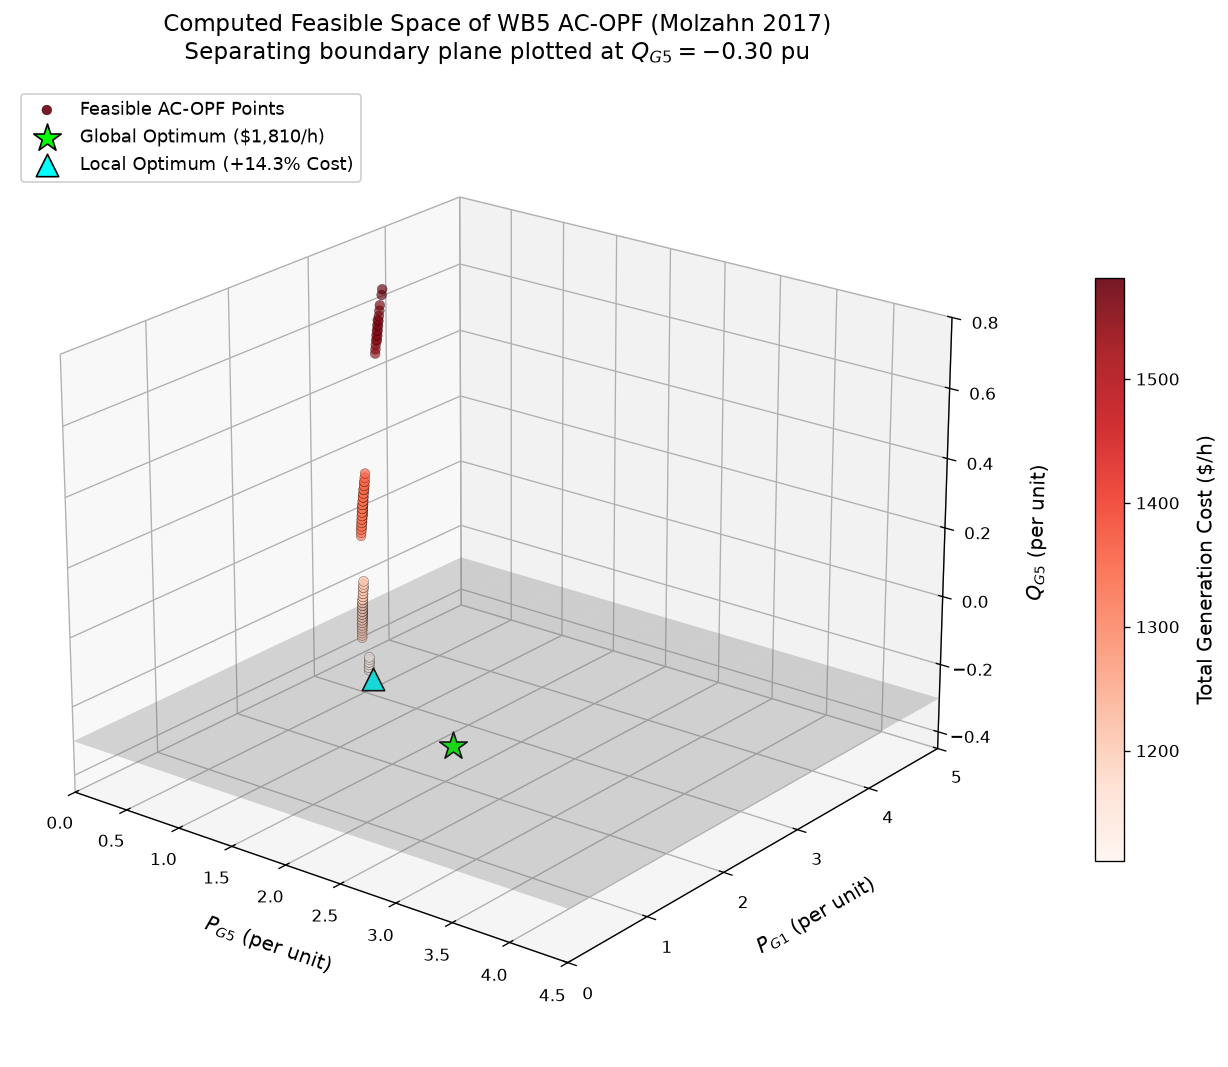

In [1]:
# =============================================================================
# CELL 5: 3D Feasible Space Visualization (Reproduction of Molzahn 2017, Fig. 3)
# =============================================================================
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Load the merged production data from disk
input_filename = "wb5_feasible_points_FINAL.pkl"

if not os.path.exists(input_filename):
    raise FileNotFoundError(f"Could not find '{input_filename}'. Make sure it is in the same folder as this notebook!")

with open(input_filename, "rb") as f:
    plot_points = pickle.load(f)
    
print(f"✔ Successfully loaded {len(plot_points):,} feasible points from '{input_filename}'.")

# 2. Extract projection axes: P_G5 (horizontal), P_G1 (vertical), Q_G5 (depth)
# We map these to match the specific axes used in Molzahn's paper.
P_G1_vals = np.array([pt['P_gen'][0] for pt in plot_points])  # Slack Bus Active Generation
P_G5_vals = np.array([pt['P_gen'][4] for pt in plot_points])  # Bus 5 Active Generation
Q_G5_vals = np.array([pt['Q_gen'][4] for pt in plot_points])  # Bus 5 Reactive Generation
cost_vals = np.array([pt['cost'] for pt in plot_points])      # $/h Generation Cost

# Safety check: Remove any NaN or Inf costs to prevent Matplotlib colormap warnings
valid_mask = ~np.isnan(cost_vals) & ~np.isinf(cost_vals)
P_G1_vals = P_G1_vals[valid_mask]
P_G5_vals = P_G5_vals[valid_mask]
Q_G5_vals = Q_G5_vals[valid_mask]
cost_vals = cost_vals[valid_mask]

# 3. Setup the 3D Figure
fig = plt.figure(figsize=(12, 9), dpi=120)
ax = fig.add_subplot(111, projection='3d')

# 4. Plot the Feasible Manifold Cloud
# We color the points by their total generation cost to highlight the economic gradient
sc = ax.scatter(P_G5_vals, P_G1_vals, Q_G5_vals, c=cost_vals, cmap='Reds', 
                s=35, alpha=0.9, edgecolors='k', linewidths=0.2, label='Feasible AC-OPF Points')

# 5. Plot the Separating Plane at Q_G5 = -0.30 pu 
# This illustrates the topological boundary that creates the disconnected component
xx, yy = np.meshgrid(np.linspace(0.0, 4.5, 10), np.linspace(0.0, 5.0, 10))
zz = -0.30 * np.ones_like(xx)
ax.plot_surface(xx, yy, zz, color='gray', alpha=0.25, rstride=1, cstride=1, edgecolor='none')

# 6. Highlight the Known Global Optimum from the Paper's Table II
# (P_G1 = 1.81 pu, P_G5 = 2.21 pu, Q_G5 = -0.30 pu)
ax.scatter([2.21], [1.81], [-0.30], color='lime', s=300, marker='*', 
           edgecolors='k', linewidths=1.0, zorder=10, label='Global Optimum ($1,810/h)')

# 7. Highlight the Known Local Optimum
# (P_G1 = 2.46 pu, P_G5 = 0.98 pu, Q_G5 = -0.30 pu)
ax.scatter([0.98], [2.46], [-0.30], color='cyan', s=180, marker='^', 
           edgecolors='k', linewidths=1.0, zorder=10, label='Local Optimum (+14.3% Cost)')

# 8. Formatting & Aesthetics
cb = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.08)
cb.set_label('Total Generation Cost ($/h)', fontsize=12, labelpad=10)

ax.set_xlabel('$P_{G5}$ (per unit)', fontsize=12, labelpad=12)
ax.set_ylabel('$P_{G1}$ (per unit)', fontsize=12, labelpad=12)
ax.set_zlabel('$Q_{G5}$ (per unit)', fontsize=12, labelpad=12)

# Set explicit viewing limits matching Figure 3 of Molzahn (2017)
ax.set_xlim([0.0, 4.5])
ax.set_ylim([0.0, 5.0])
ax.set_zlim([-0.45, 0.8])

ax.set_title("Computed Feasible Space of WB5 AC-OPF (Molzahn 2017)\n"
             "Separating boundary plane plotted at $Q_{G5} = -0.30$ pu", fontsize=14, pad=15)

# Optimal perspective angle to view the disconnected component slicing below Q_G5 = -0.30
ax.view_init(elev=22, azim=-52)
ax.legend(loc='upper left', framealpha=0.95, fontsize=11)

plt.tight_layout()

# Save a high-res copy for your documentation/presentations
output_img = "WB5_Molzahn_Fig3_Replication.png"
plt.savefig(output_img, dpi=300, bbox_inches='tight')
print(f"✔ High-resolution figure saved as '{output_img}'!")

# Display interactively
plt.show()

In [ ]:
# =============================================================================
# CELL 5: High-Density 3D Visualization (Tuned to Match Paramotopy Visuals)
# =============================================================================
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

input_filename = "wb5_feasible_points_FINAL.pkl"
with open(input_filename, "rb") as f:
    plot_points = pickle.load(f)

print(f"✔ Rendering dense manifold from {len(plot_points):,} points...")

P_G1_vals = np.array([pt['P_gen'][0] for pt in plot_points])
P_G5_vals = np.array([pt['P_gen'][4] for pt in plot_points])
Q_G5_vals = np.array([pt['Q_gen'][4] for pt in plot_points])
cost_vals = np.array([pt['cost'] for pt in plot_points])

fig = plt.figure(figsize=(12, 10), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# 1. THE DENSE CLOUD (Tuned to mimic a continuous surface)
# We use gist_heat_r to match Molzahn's White->Red->Black cost gradient
sc = ax.scatter(P_G5_vals, P_G1_vals, Q_G5_vals, c=cost_vals, cmap='gist_heat_r', 
                s=4,               # Tiny marker size for surface blending
                alpha=0.6,         # Transparency allows the volume to look smooth
                edgecolors='none', # Crucial: Removes the dot outlines
                vmin=900, vmax=1600) # Lock the colorbar to the paper's exact range

# 2. THE SEPARATING PLANE (Q_G5 = -0.30)
xx, yy = np.meshgrid(np.linspace(-1, 5, 10), np.linspace(0, 5, 10))
zz = -0.30 * np.ones_like(xx)
ax.plot_surface(xx, yy, zz, color='lightgray', alpha=0.5, rstride=1, cstride=1, edgecolor='none')

# 3. BENCHMARK OPTIMA (Matched to the paper's styling)
ax.scatter([2.21], [1.81], [-0.30], color='lime', s=400, marker='*', 
           edgecolors='black', linewidths=1.0, zorder=10, label='Global Optimum ($1,810/h)')
ax.scatter([0.98], [2.46], [-0.30], color='blue', s=180, marker='v', # 'v' is downward triangle
           edgecolors='black', linewidths=1.0, zorder=10, label='Local Optimum')

# 4. AESTHETICS & CAMERA ANGLE
cb = plt.colorbar(sc, ax=ax, shrink=0.5, pad=0.05)
cb.set_label('Total Generation Cost ($/h)', fontsize=12)

ax.set_xlabel('$P_{G5}$ (per unit)', fontsize=12, labelpad=10)
ax.set_ylabel('$P_{G1}$ (per unit)', fontsize=12, labelpad=10)
ax.set_zlabel('$Q_{G5}$ (per unit)', fontsize=12, labelpad=10)

# Exact limits from Figure 3
ax.set_xlim([-1.0, 5.0])
ax.set_ylim([0.0, 5.0])
ax.set_zlim([-0.6, 0.8])

# Exact Camera Angle to match Figure 3 perspective
ax.view_init(elev=15, azim=-65)
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

In [2]:
# chatgpt
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

from pypower.api import runopf, ppoption
from pypower.idx_gen import PG, QG, PMIN, PMAX

# -----------------------------
# WB5 case in Python / PYPOWER format
# -----------------------------
def make_WB5():
    mpc = {
        "version": "2",
        "baseMVA": 100.0,
        "bus": np.array([
            [1, 3,   0,   0, 0, 0, 1, 1.0,    0,   345, 1, 1.05, 0.95],
            [2, 1, 130,  20, 0, 0, 1, 1.0,  -10,   345, 1, 1.05, 0.95],
            [3, 1, 130,  20, 0, 0, 1, 1.0,  -20,   345, 1, 1.05, 0.95],
            [4, 1,  65,  10, 0, 0, 1, 1.0, -135,   345, 1, 1.05, 0.95],
            [5, 2,   0,   0, 0, 0, 1, 1.0, -140,   345, 1, 1.05, 0.95],
        ], dtype=float),
        "gen": np.array([
            [1, 500, 50, 1800, -30, 1, 100, 1, 5000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [5,   0,  0, 1800, -30, 1, 100, 1, 5000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        ], dtype=float),
        "branch": np.array([
            [1, 2, 0.04, 0.09, 0.00, 2500, 2500, 2500, 0, 0, 1, -360, 360],
            [1, 3, 0.05, 0.10, 0.00, 2500, 2500, 2500, 0, 0, 1, -360, 360],
            [2, 4, 0.55, 0.90, 0.45, 2500, 2500, 2500, 0, 0, 1, -360, 360],
            [3, 5, 0.55, 0.90, 0.45, 2500, 2500, 2500, 0, 0, 1, -360, 360],
            [4, 5, 0.06, 0.10, 0.00, 2500, 2500, 2500, 0, 0, 1, -360, 360],
            [2, 3, 0.07, 0.09, 0.00, 2500, 2500, 2500, 0, 0, 1, -360, 360],
        ], dtype=float),
        "areas": np.array([[1, 5]], dtype=float),
        "gencost": np.array([
            [2, 2, 0, 3, 0, 4.00, 0],
            [2, 2, 0, 3, 0, 1.00, 0],
        ], dtype=float),
    }
    return mpc

mpc0 = make_WB5()

ppopt = ppoption(VERBOSE=0, OUT_ALL=0)
res = runopf(mpc0, ppopt)
print("OPF success:", bool(res["success"]))
print("Objective:", res["f"])

OPF success: True
Objective: 1082.3325036854237


C:\Users\firda\AppData\Local\Temp\ipykernel_20780\1659207209.py:52: RuntimeWarning: All-NaN slice encountered
  norm = Normalize(vmin=np.nanmin(C), vmax=np.nanmax(C))


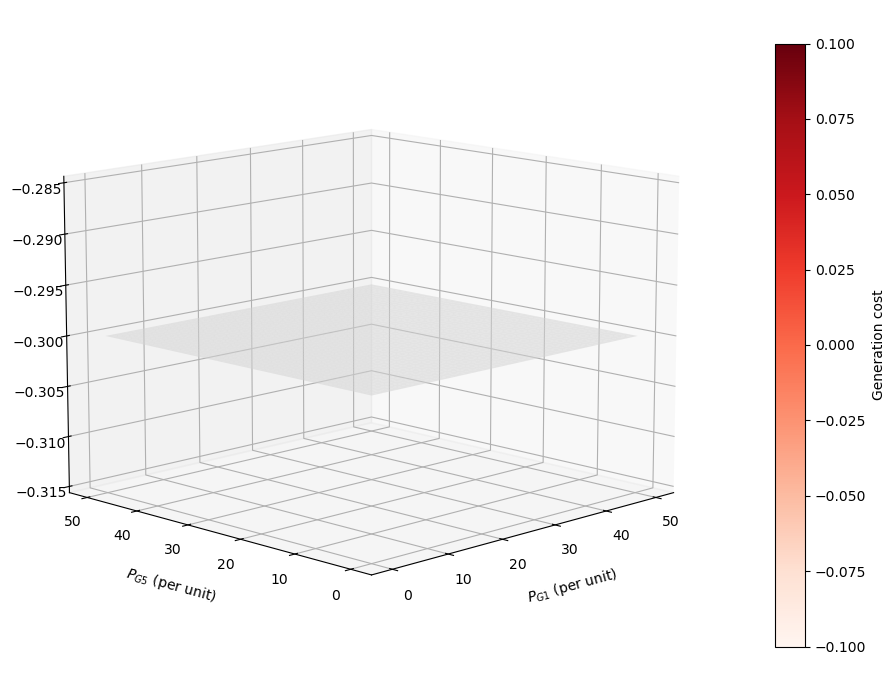

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from copy import deepcopy

from pypower.api import runopf, ppoption
from pypower.idx_gen import PG, QG, PMIN, PMAX

def solve_fixed_pg(pg1_mw, pg5_mw, base_case, ppopt):
    case = deepcopy(base_case)

    # Fix generator active powers by setting Pmin = Pmax = Pg
    case["gen"][0, PG] = pg1_mw
    case["gen"][0, PMIN] = pg1_mw
    case["gen"][0, PMAX] = pg1_mw

    case["gen"][1, PG] = pg5_mw
    case["gen"][1, PMIN] = pg5_mw
    case["gen"][1, PMAX] = pg5_mw

    r = runopf(case, ppopt)
    if not r["success"]:
        return None

    qg5_pu = r["gen"][1, QG] / r["baseMVA"]
    cost = r["f"]
    return qg5_pu, cost

# Grid in MW
Pg1_vals = np.linspace(0, 5000, 45)
Pg5_vals = np.linspace(0, 5000, 45)

Z = np.full((len(Pg5_vals), len(Pg1_vals)), np.nan)   # Q_G5 in pu
C = np.full((len(Pg5_vals), len(Pg1_vals)), np.nan)   # objective cost

for i, pg5 in enumerate(Pg5_vals):
    for j, pg1 in enumerate(Pg1_vals):
        out = solve_fixed_pg(pg1, pg5, mpc0, ppopt)
        if out is not None:
            qg5_pu, cost = out
            Z[i, j] = qg5_pu
            C[i, j] = cost

# Mesh for plotting
P1g, P5g = np.meshgrid(Pg1_vals / mpc0["baseMVA"], Pg5_vals / mpc0["baseMVA"])

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Feasible surface colored by cost
norm = Normalize(vmin=np.nanmin(C), vmax=np.nanmax(C))
facecolors = cm.Reds(norm(C))
facecolors[np.isnan(Z)] = (0, 0, 0, 0)

surf = ax.plot_surface(
    P1g, P5g, Z,
    facecolors=facecolors,
    linewidth=0,
    antialiased=True,
    shade=False
)

# Gray lower reactive power limit plane, like the paper
Q_plane = -0.30 * np.ones_like(Z)
ax.plot_surface(
    P1g, P5g, Q_plane,
    color="lightgray",
    alpha=0.55,
    linewidth=0,
    shade=False
)

# Example markers; replace with your actual global/local optimum points
# ax.scatter(pg1_star, pg5_star, qg5_star, marker='*', s=220, color='limegreen', edgecolor='k')
# ax.scatter(pg1_local, pg5_local, qg5_local, marker='v', s=120, color='royalblue', edgecolor='k')

ax.set_xlabel(r"$P_{G1}$ (per unit)", labelpad=12)
ax.set_ylabel(r"$P_{G5}$ (per unit)", labelpad=12)
ax.set_zlabel(r"$Q_{G5}$ (per unit)", labelpad=12)
ax.view_init(elev=12, azim=-135)

mappable = cm.ScalarMappable(norm=norm, cmap=cm.Reds)
mappable.set_array([])
cbar = fig.colorbar(mappable, ax=ax, pad=0.08, shrink=0.9)
cbar.set_label("Generation cost")
plt.tight_layout()
plt.show()

# ++++++++++++++++++++++++++++++++++++++++++++++++

Grid: 41 × 11 × 11 = 4,961 points
Starts per point: 7  →  34,727 total solves
This typically takes 3–8 minutes on a modern laptop.

  [10/41]  P_G5 = 0.90 pu  →    195 feasible points collected
  [20/41]  P_G5 = 1.90 pu  →    195 feasible points collected
  [30/41]  P_G5 = 2.90 pu  →    196 feasible points collected
  [40/41]  P_G5 = 3.90 pu  →    196 feasible points collected
  [41/41]  P_G5 = 4.00 pu  →    196 feasible points collected

Done.  Total feasible points: 196


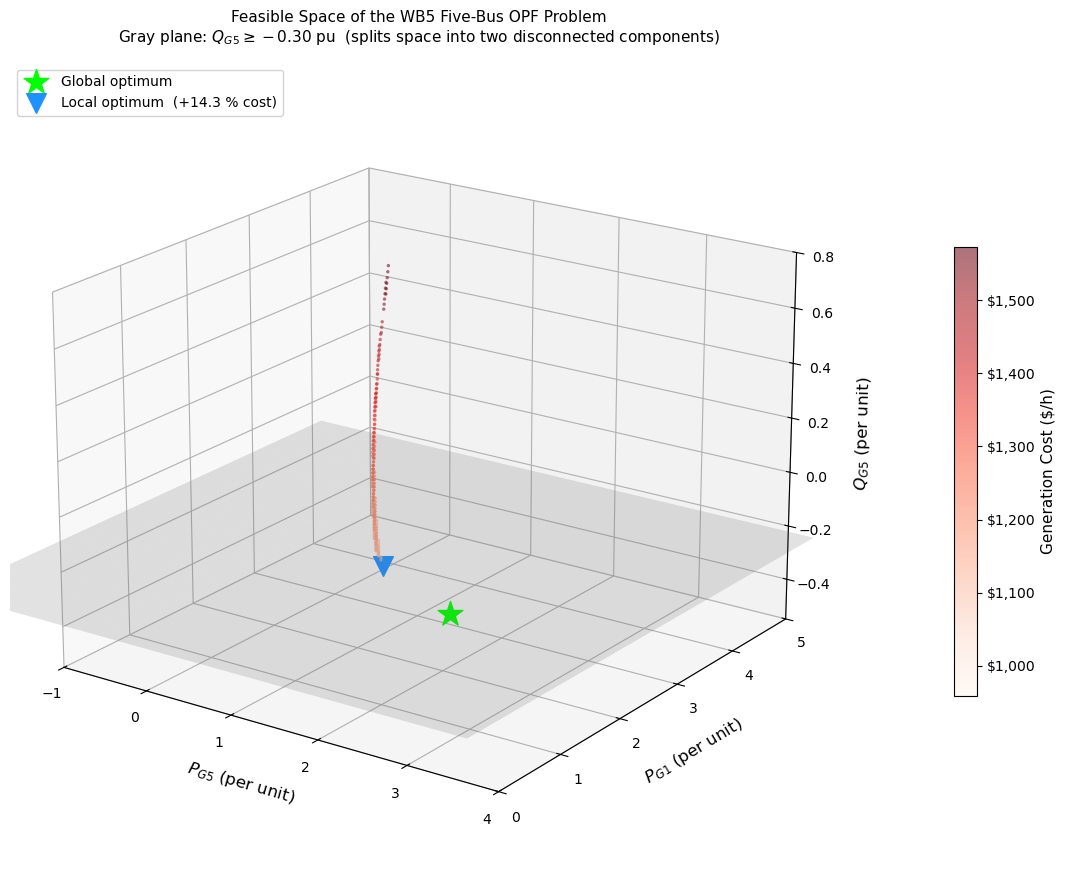

Figure saved → WB5_feasible_space.png


In [ ]:
# claude
# =============================================================================
# WB5 Five-Bus OPF — Feasible Space Visualization
# Reproduces Fig. 3 from Molzahn (2017) / Bukhsh et al. (2013)
#
# Approach:
#   • Discretize (P_G5, V_G5, V_G1) — the generator "control" variables
#   • Solve the AC power flow at every grid point (multiple starting points
#     to capture both disconnected components)
#   • Keep points that satisfy all OPF constraints
#   • Plot the feasible set in (P_G1, P_G5, Q_G5) space, coloured by cost
# =============================================================================

# ── Cell 1 · Imports ──────────────────────────────────────────────────────────
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D          # needed for 3-D axes
import warnings
warnings.filterwarnings("ignore")

# ── Cell 2 · WB5 System Data (per unit, 100 MVA base) ────────────────────────
#
# Bus layout (0-indexed):
#   Bus 0  →  Slack / Generator G1
#   Bus 1  →  PQ load  (1.30 pu real, 0.20 pu reactive)
#   Bus 2  →  PQ load  (1.30 pu real, 0.20 pu reactive)
#   Bus 3  →  PQ load  (0.65 pu real, 0.10 pu reactive)
#   Bus 4  →  PV  / Generator G5  (no load)
#
# Generator limits  (same for both):
#   Q_min = −0.30 pu,  Q_max = 18.0 pu  (from Qmin=−30 / Qmax=1800 MVAr)
#
# Cost:  400·P_G1 + 100·P_G5  [$/h]
#        (c1 = 4 $/MWh × 100 MVA base = 400; c1 = 1 $/MWh → 100)

n = 5

# Branches: (from_bus, to_bus, R_pu, X_pu, B_total_pu)
branch_data = [
    (0, 1, 0.04, 0.09, 0.00),
    (0, 2, 0.05, 0.10, 0.00),
    (1, 3, 0.55, 0.90, 0.45),
    (2, 4, 0.55, 0.90, 0.45),
    (3, 4, 0.06, 0.10, 0.00),
    (1, 2, 0.07, 0.09, 0.00),
]

# Build Y-bus
Y = np.zeros((n, n), dtype=complex)
for (i, j, r, x, bc) in branch_data:
    ys  = 1.0 / (r + 1j * x)   # series admittance
    ysh = 1j * bc / 2.0         # half-line charging susceptance
    Y[i, i] += ys + ysh;  Y[j, j] += ys + ysh
    Y[i, j] -= ys;         Y[j, i] -= ys

G, B = Y.real, Y.imag

# Load demands
Pd = np.array([0.00, 1.30, 1.30, 0.65, 0.00])   # pu
Qd = np.array([0.00, 0.20, 0.20, 0.10, 0.00])   # pu

# Bounds
V_MIN,  V_MAX  = 0.95, 1.05
QG_MIN, QG_MAX = -0.30, 18.0

# Known OPF solutions (from Molzahn 2017, Table in Section V)
GLOBAL_SOL = (1.81, 2.21, -0.30)   # (P_G1, P_G5, Q_G5)  pu
LOCAL_SOL  = (2.46, 0.98, -0.30)

# ── Cell 3 · Power Flow Solver ────────────────────────────────────────────────
def bus_powers(Vm, th):
    """Vectorised active/reactive power injections at all buses."""
    d = th[:, None] - th[None, :]
    P = (Vm[:, None] * Vm[None, :] * (G * np.cos(d) + B * np.sin(d))).sum(axis=1)
    Q = (Vm[:, None] * Vm[None, :] * (G * np.sin(d) - B * np.cos(d))).sum(axis=1)
    return P, Q


def solve_pf(P_G5, V_G1, V_G5, x0):
    """
    Newton–Raphson power flow for WB5.

    Parameters
    ----------
    P_G5 : float  — active power injection of G5 (bus 4), pu
    V_G1 : float  — voltage magnitude at slack bus (bus 0), pu
    V_G5 : float  — voltage magnitude at PV bus (bus 4), pu
    x0   : array  — initial guess [θ1, θ2, θ3, θ4, V1, V2, V3]

    Returns
    -------
    dict with P_G1, Q_G1, Q_G5, Vm  —  or None if no convergence.
    """
    # Net power specs at non-slack buses (buses 1, 2, 3, 4)
    P_spec = np.array([-Pd[1], -Pd[2], -Pd[3], P_G5])
    Q_spec = np.array([-Qd[1], -Qd[2], -Qd[3]])

    def residuals(x):
        th = np.array([0., x[0], x[1], x[2], x[3]])
        Vm = np.array([V_G1, x[4], x[5], x[6], V_G5])
        P, Q = bus_powers(Vm, th)
        return [
            P_spec[0] - P[1], P_spec[1] - P[2],
            P_spec[2] - P[3], P_spec[3] - P[4],
            Q_spec[0] - Q[1], Q_spec[1] - Q[2], Q_spec[2] - Q[3],
        ]

    sol, info, ier, _ = fsolve(residuals, x0, full_output=True, xtol=1e-10)
    if ier != 1 or np.max(np.abs(info["fvec"])) > 1e-6:
        return None

    th = np.array([0., sol[0], sol[1], sol[2], sol[3]])
    Vm = np.array([V_G1, sol[4], sol[5], sol[6], V_G5])
    P, Q = bus_powers(Vm, th)

    return dict(P_G1=P[0], Q_G1=Q[0], Q_G5=Q[4], Vm=Vm)


# ── Cell 4 · Grid Sweep ───────────────────────────────────────────────────────
#
# We discretise the generator "setpoints" and voltage magnitudes,
# solve the power flow at each point, and keep feasible solutions.
#
# Grid resolution — feel free to reduce step sizes for a finer plot
# (finer = longer runtime; ~0.05 / 0.005 gives a smoother surface).

P5_vals = np.arange(0.0,  4.01, 0.10)    # 41 values
V5_vals = np.arange(0.95, 1.051, 0.01)   # 11 values
V1_vals = np.arange(0.95, 1.051, 0.01)   # 11 values  → 41×11×11 = 4 951 grid pts

# Multiple starting points — essential to capture BOTH disconnected components.
# The component containing the local optimum needs reversed/large angle starts.
X0_LIST = [
    [ 0.0,  0.0,  0.0,  0.0,  1.00, 1.00, 1.00],   # flat start
    [-0.1, -0.2, -0.3, -0.4,  0.97, 0.97, 0.97],
    [ 0.1,  0.2,  0.1,  0.2,  1.02, 1.02, 1.02],
    [ 0.0,  0.0,  0.0, -1.0,  1.00, 1.00, 1.00],   # large negative θ₄
    [ 0.0,  0.0,  0.0,  1.0,  1.00, 1.00, 1.00],   # large positive  θ₄
    [-0.5, -0.5, -0.3, -1.5,  0.95, 0.95, 0.95],
    [ 0.5,  0.5,  0.3,  0.5,  1.05, 1.05, 1.05],
]

pts = []   # feasible points: [P_G1, P_G5, Q_G5, cost]

n_grid = len(P5_vals) * len(V5_vals) * len(V1_vals)
print(f"Grid: {len(P5_vals)} × {len(V5_vals)} × {len(V1_vals)} = {n_grid:,} points")
print(f"Starts per point: {len(X0_LIST)}  →  {n_grid*len(X0_LIST):,} total solves")
print("This typically takes 3–8 minutes on a modern laptop.\n")

for ip, P5 in enumerate(P5_vals):
    for V5 in V5_vals:
        for V1 in V1_vals:
            seen = set()
            for x0 in X0_LIST:
                res = solve_pf(P5, V1, V5, x0)
                if res is None:
                    continue

                P1, Q1, Q5 = res["P_G1"], res["Q_G1"], res["Q_G5"]
                Vm = res["Vm"]

                # ── de-duplicate (same solution from different starts) ────────
                key = tuple(np.round([P1, Q1, Q5, *Vm], 2))
                if key in seen:
                    continue
                seen.add(key)

                # ── feasibility checks ───────────────────────────────────────
                EPS = 1e-4
                if P1 < -EPS:
                    continue
                if not (QG_MIN - EPS <= Q1 <= QG_MAX + EPS):
                    continue
                if not (QG_MIN - EPS <= Q5 <= QG_MAX + EPS):
                    continue
                if not all(V_MIN - EPS <= v <= V_MAX + EPS for v in Vm):
                    continue

                cost = 400.0 * P1 + 100.0 * P5
                pts.append([P1, P5, Q5, cost])

    if (ip + 1) % 10 == 0 or ip == len(P5_vals) - 1:
        print(f"  [{ip+1:2d}/{len(P5_vals)}]  P_G5 = {P5:.2f} pu  "
              f"→  {len(pts):5d} feasible points collected")

pts = np.array(pts)
print(f"\nDone.  Total feasible points: {len(pts):,}")


# ── Cell 5 · 3-D Plot ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection="3d")

P1_p   = pts[:, 0]
P5_p   = pts[:, 1]
Q5_p   = pts[:, 2]
cost_p = pts[:, 3]

# ── feasible-space scatter (coloured by generation cost) ─────────────────────
sc = ax.scatter(
    P5_p, P1_p, Q5_p,
    c=cost_p, cmap="Reds",
    vmin=cost_p.min(), vmax=cost_p.max(),
    s=6, alpha=0.55, linewidths=0,
)

# ── gray plane  Q_G5 = −0.30 pu ──────────────────────────────────────────────
# This is the reactive-power lower limit that splits the feasible space.
pg5g, pg1g = np.meshgrid(np.linspace(-2, 4, 30), np.linspace(-0.5, 5.5, 30))
ax.plot_surface(pg5g, pg1g, np.full_like(pg5g, QG_MIN),
                alpha=0.18, color="gray", zorder=0)

# ── known OPF solutions ───────────────────────────────────────────────────────
gP1, gP5, gQ5 = GLOBAL_SOL
lP1, lP5, lQ5 = LOCAL_SOL

ax.scatter([gP5], [gP1], [gQ5],
           c="lime", s=350, marker="*",
           zorder=10, depthshade=False, label="Global optimum")
ax.scatter([lP5], [lP1], [lQ5],
           c="dodgerblue", s=200, marker="v",
           zorder=10, depthshade=False,
           label=f"Local optimum  (+14.3 % cost)")

# ── colorbar ──────────────────────────────────────────────────────────────────
cbar = plt.colorbar(sc, ax=ax, shrink=0.55, pad=0.10, aspect=20)
cbar.set_label("Generation Cost ($/h)", fontsize=11)
cbar.ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# ── labels & formatting ───────────────────────────────────────────────────────
ax.set_xlabel("$P_{G5}$ (per unit)", labelpad=10, fontsize=12)
ax.set_ylabel("$P_{G1}$ (per unit)", labelpad=10, fontsize=12)
ax.set_zlabel("$Q_{G5}$ (per unit)", labelpad=10, fontsize=12)

ax.set_title(
    "Feasible Space of the WB5 Five-Bus OPF Problem\n"
    r"Gray plane: $Q_{G5} \geq -0.30$ pu  (splits space into two disconnected components)",
    fontsize=11, pad=15,
)

ax.set_xlim([-1, 4])
ax.set_ylim([ 0, 5])
ax.set_zlim([-0.55, 0.8])

ax.view_init(elev=20, azim=-55)
ax.legend(loc="upper left", fontsize=10, framealpha=0.85)

plt.tight_layout()
plt.savefig("WB5_feasible_space.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → WB5_feasible_space.png")

# ++++++++++++++++++++++++++++++++++++++++++++++++

In [ ]:
# gemini